#Introduction

This is a comparison between CNN and MLP models for the DDoS dataset.

CNNs are Convolutional Neural Networks that use convolutional layers in order to find patters in spatial data.
Spatial data is data that correlates to a specific geometric location, either in space or time. By applying filters over these features, CNNs are able to find features in the data.

MLP stands for Multi-layer Perceptron, MLPs are sometimes known as "vanilla" networks. They are one of the modern foundational machine learning models for categorization.

Both of these models are implemented using Keras Sequential model, the only difference is the use of convolutional layers. The point of comparison is because these convolutional layers add a lot of computation to the model.
If we can remove these layers with out effecting the accuracy then I believe we should do so.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
ddos_data = pd.read_csv('https://raw.githubusercontent.com/RayFarrington/MLTests/refs/heads/master/data/DDOS_Data.csv')
#https://www.kaggle.com/code/atulkumar011/ddos-attack-detection-classification-a03d6b
ddos_data.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0


#Data Cleaning

Many of the decisions for the features I removed or added are based on EDA research from which can be found on my original DDosModel notebook.

In [ ]:
ddos_data_clean = ddos_data.copy()
ddos_data_clean.drop(columns=['byteperflow', 'pktperflow', 'tot_dur'], inplace=True)
ddos_data_clean.head()

,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,3,1943,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2,1943,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,3,1943,451,0,UDP,3,3413,3665,0,0.0,0.0,0


I am adding the median value to rx_kbps, but I'm adding the median rx to the tx to get the total to keep tot = tx + rx as true

In [ ]:
median_val = ddos_data_clean['rx_kbps'].median()
ddos_data_clean.fillna({'rx_kbps': median_val}, inplace=True)

tot_index = ddos_data_clean[ddos_data_clean['tot_kbps'].isnull()].index
ddos_data_clean.loc[tot_index, 'tot_kbps'] = ddos_data_clean.loc[tot_index, 'tx_kbps'] + ddos_data_clean.loc[tot_index, 'rx_kbps']


#Feature Engineering

In [ ]:
ddos_data_clean['bytes_per_packet'] = ddos_data_clean['bytecount'] / (ddos_data_clean['pktcount'] + 1e-6)

ddos_data_clean['tx_rx_ratio_bytes'] = ddos_data_clean['tx_bytes'] / (ddos_data_clean['rx_bytes'] + 1e-6)

In [ ]:
from sklearn.preprocessing import RobustScaler

ddos_data_clean['pktrate'] = ddos_data_clean['pktrate'].clip(lower=0)

numerical_features = ddos_data_clean.select_dtypes(include=['int64', 'float64']).drop(columns=['switch', 'Pairflow', 'port_no', 'label']).columns

for col in numerical_features:
  ddos_data_clean[col] = np.log1p(ddos_data_clean[col])

scaler = RobustScaler()
ddos_data_clean[numerical_features] = scaler.fit_transform(ddos_data_clean[numerical_features])
ddos_data_clean[numerical_features].describe()

,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,bytes_per_packet,tx_rx_ratio_bytes
count,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000
mean,0.078185,-0.268578,-0.104216,-0.158596,-0.176599,0.017210,0.053168,-0.330822,-0.140026,-0.219450,0.450004,0.442580,0.270034,4.235333e-01,0.814829
std,0.581877,0.533504,0.492515,0.928648,0.959654,0.613093,0.840351,0.471134,0.470229,0.483200,0.616169,0.559272,0.474241,5.580558e-01,2.137325
min,-1.087163,-2.238803,-2.284671,-4.720290,-18.045769,-1.000000,-4.761509,-0.967799,-0.723142,-0.909841,0.000000,0.000000,-0.195013,-1.951437e+00,-0.504185
25%,-0.359170,-0.833213,-0.640767,-0.578273,-0.527401,-0.584963,-0.328695,-0.967799,-0.661797,-0.776189,0.000000,0.000000,-0.195013,-5.004106e-09,-0.451684
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
75%,0.640830,0.166787,0.359233,0.421727,0.472599,0.415037,0.671305,0.032201,0.338203,0.223811,1.000000,1.000000,0.804987,1.000000e+00,0.548316
max,0.890943,0.378591,0.455074,1.716435,0.792041,1.584963,1.576650,0.144111,0.556192,0.405570,1.796229,1.548864,1.008448,1.079522e+00,8.074342


In [ ]:
features_to_encode = ['Protocol']
features_to_drop_entirely = ['src', 'dst', 'switch', 'Pairflow', 'port_no']

# Drop features that are not to be encoded nor kept
ddos_data_temp = ddos_data_clean.drop(columns=features_to_drop_entirely, errors='ignore')

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Add handle_unknown and sparse_output for robustness

encoded_data = pd.DataFrame(
    ohe.fit_transform(ddos_data_temp[features_to_encode]),
    columns=ohe.get_feature_names_out(features_to_encode)
)

# Now, drop the original 'Protocol' column from ddos_data_temp before concatenating encoded_data
ddos_data_encoded = pd.concat([ddos_data_temp.drop(columns=features_to_encode), encoded_data], axis=1)

ddos_data_encoded.head()

,dt,pktcount,bytecount,dur,dur_nsec,flows,packetins,pktrate,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label,bytes_per_packet,tx_rx_ratio_bytes,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,-0.028584,0.011798,0.292789,-0.780515,0.489256,-0.584963,-0.328695,0.084263,0.343984,-0.766629,0.0,0.0,-0.195013,0,1.009661,6.758410,0.0,0.0,1.0
1,-0.017726,0.227178,0.442258,0.092986,0.511827,-1.000000,-0.328695,0.084263,-0.682324,-0.776696,0.0,0.0,-0.195013,0,1.009661,0.005606,0.0,0.0,1.0
2,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.683523,-0.874804,0.0,0.0,-0.195013,0,1.009661,0.463133,0.0,0.0,1.0
3,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.686310,-0.857536,0.0,0.0,-0.195013,0,1.009661,0.355766,0.0,0.0,1.0
4,-0.028584,0.156664,0.393323,-0.193035,0.524128,-0.584963,-0.328695,0.084263,-0.693860,-0.772893,0.0,0.0,-0.195013,0,1.009661,-0.049464,0.0,0.0,1.0


#Training the model

For this comparison I compared two versions for each model. One for the whole data set and one for the 5 most correlated features. The models with less features will perform worse, but should make it easier to see any differences in accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def train_mlp_model(X, y, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):

    # First split: 80% train, 20% temporary for validation and test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(val_size + test_size), random_state=random_state)

    # Second split: From the 20% temporary, split into 10% validation and 10% test
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_size / (val_size + test_size), random_state=random_state)

    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("MLP Model Summary:")
    model.summary()

    print("\nTraining MLP model...")
    history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val, y_val), verbose=1)
    print("MLP model training complete.")

    return model, history, X_test, y_test


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
def train_cnn_model(X, y, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(val_size + test_size), random_state=random_state)

    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=test_size / (val_size + test_size), random_state=random_state)

    # Data needs to be reshaped in order to fit into the Conv2D layers. This is part of the reason we don't see a lot of
    # performace gain in the CNN, because the data is simply not spatial
    X_train_ = X_train.to_numpy().reshape(X_train.shape[0], X_train.shape[1], 1, 1)
    X_val_ = X_val.to_numpy().reshape(X_val.shape[0], X_val.shape[1], 1, 1)
    X_test_ = X_test.to_numpy().reshape(X_test.shape[0], X_test.shape[1], 1, 1)

    model = Sequential([
        Conv2D(32, (3, 1), activation="relu", padding="same", input_shape=(X_train_.shape[1], X_train_.shape[2], X_train_.shape[3])),
        MaxPooling2D((2, 1)),
        Conv2D(64, (3, 1), activation="relu", padding="same"),
        Flatten(),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("CNN Model Summary:")
    model.summary()

    print("\nTraining CNN model...")
    history = model.fit(X_train_, y_train, epochs=10, batch_size=32,
                        validation_data=(X_val_, y_val), verbose=1)
    print("CNN model training complete.")

    return model, history, X_test_, y_test


In [ ]:
def evaluate_model(model, X_test_reshaped, y_test):
  y_pred_prob = model.predict(X_test_reshaped)
  y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

  conf_matrix = confusion_matrix(y_test, y_pred)
  print("Confusion Matrix:")
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Predicted Normal', 'Predicted DDoS'],
              yticklabels=['Actual Normal', 'Actual DDoS'])
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))
  print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

In [ ]:
#this funtion plots the ROC curves of a set of models
def plot_roc_curves(models_data):
  plt.figure(figsize=(10, 8))
  for name, model, X_test, y_test in models_data:
    y_prob = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

In [ ]:
X_mlp = ddos_data_encoded.drop('label', axis=1)
y_mlp = ddos_data_encoded['label']
model_mlp, histroy_mlp, X_test_mlp, y_test_mlp = train_mlp_model(X_mlp, y_mlp)

MLP Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8170 - loss: 0.3457 - val_accuracy: 0.9534 - val_loss: 0.1136
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9497 - loss: 0.1188 - val_accuracy: 0.9607 - val_loss: 0.0878
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9583 - loss: 0.0974 - val_accuracy: 0.9726 - val_loss: 0.0705
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9663 - loss: 0.0819 - val_accuracy: 0.9657 - val_loss: 0.0732
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9710 - loss: 0.0708 - val_accuracy: 0.9849 - val_loss: 0.0448
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9774 - loss: 0.0585 - val_accuracy: 0.9838 - val_loss: 0.0410
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9788 - loss: 0.0530 - val_accuracy: 0.9861 - val_loss: 0.0368
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0

In [ ]:
X_mlp_five = ddos_data_encoded[['pktcount', 'bytes_per_packet', 'bytecount', 'pktrate', 'Protocol_UDP']]
y_mlp_five = ddos_data_encoded['label']
model_mlp_five, histroy_mlp_five, X_test_mlp_five, y_test_mlp_five = train_mlp_model(X_mlp_five, y_mlp_five)

MLP Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8230 - loss: 0.3525 - val_accuracy: 0.9272 - val_loss: 0.1611
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9273 - loss: 0.1613 - val_accuracy: 0.9340 - val_loss: 0.1436
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9299 - loss: 0.1495 - val_accuracy: 0.9374 - val_loss: 0.1346
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9363 - loss: 0.1361 - val_accuracy: 0.9381 - val_loss: 0.1324
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9366 - loss: 0.1347 - val_accuracy: 0.9398 - val_loss: 0.1286
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9369 - loss: 0.1321 - val_accuracy: 0.9392 - val_loss: 0.1266
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9385 - loss: 0.1298 - val_accuracy: 0.9376 - val_loss: 0.1248
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 

In [ ]:
X_cnn = ddos_data_encoded.drop('label', axis=1)
y_cnn = ddos_data_encoded['label']
model_cnn, histroy_cnn, X_test_cnn, y_test_cnn = train_cnn_model(X_cnn, y_cnn)


CNN Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 18, 1, 32)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 9, 1, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,321 (313.75 KB)

 Trainable params: 80,321 (313.75 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8536 - loss: 0.2895 - val_accuracy: 0.9544 - val_loss: 0.1150
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9574 - loss: 0.1040 - val_accuracy: 0.9634 - val_loss: 0.0878
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9684 - loss: 0.0793 - val_accuracy: 0.9758 - val_loss: 0.0613
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9732 - loss: 0.0651 - val_accuracy: 0.9791 - val_loss: 0.0508
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9778 - loss: 0.0547 - val_accuracy: 0.9783 - val_loss: 0.0539
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9787 - loss: 0.0518 - val_accuracy: 0.9822 - val_loss: 0.0454
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9814 - loss: 0.0463 - val_accuracy: 0.9701 - val_loss: 0.0788
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - acc

In [ ]:
X_cnn_five = ddos_data_encoded[['pktcount', 'bytes_per_packet', 'bytecount', 'pktrate', 'Protocol_UDP']]
y_cnn_five = ddos_data_encoded['label']
model_cnn_five, histroy_cnn_five, X_test_cnn_five, y_test_cnn_five = train_cnn_model(X_cnn_five, y_cnn_five)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 5, 1, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 2, 1, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,977 (89.75 KB)

 Trainable params: 22,977 (89.75 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8642 - loss: 0.2870 - val_accuracy: 0.9259 - val_loss: 0.1677
Epoch 2/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9302 - loss: 0.1538 - val_accuracy: 0.9335 - val_loss: 0.1481
Epoch 3/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9330 - loss: 0.1450 - val_accuracy: 0.9352 - val_loss: 0.1412
Epoch 4/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9358 - loss: 0.1374 - val_accuracy: 0.9405 - val_loss: 0.1399
Epoch 5/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9368 - loss: 0.1319 - val_accuracy: 0.9389 - val_loss: 0.1331
Epoch 6/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9394 - loss: 0.1280 - val_accuracy: 0.9435 - val_loss: 0.1279
Epoch 7/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9417 - loss: 0.1240 - val_accuracy: 0.9401 - val_loss: 0.1314
Epoch 8/10
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy:

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:


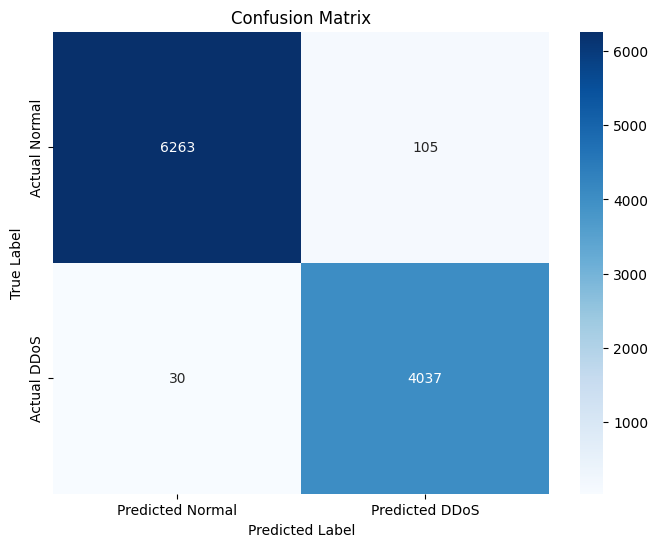


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6368
           1       0.97      0.99      0.98      4067

    accuracy                           0.99     10435
   macro avg       0.98      0.99      0.99     10435
weighted avg       0.99      0.99      0.99     10435

Accuracy Score: 0.9871


In [ ]:
evaluate_model(model_mlp, X_test_mlp, y_test_mlp)

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Confusion Matrix:


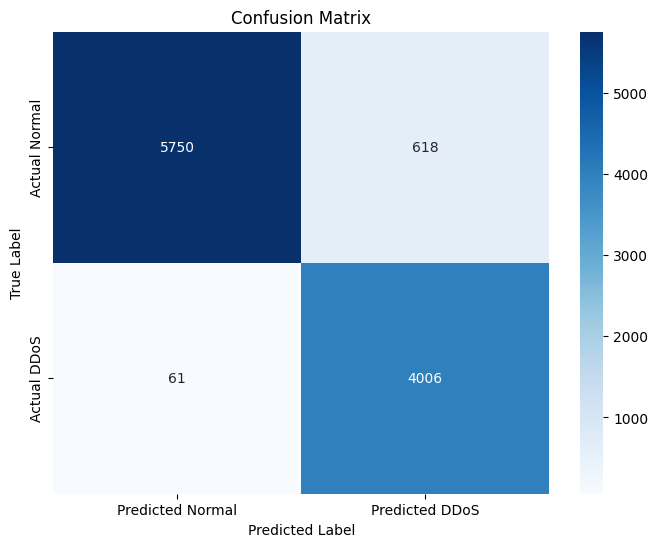


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      6368
           1       0.87      0.99      0.92      4067

    accuracy                           0.93     10435
   macro avg       0.93      0.94      0.93     10435
weighted avg       0.94      0.93      0.94     10435

Accuracy Score: 0.9349


In [ ]:
evaluate_model(model_mlp_five, X_test_mlp_five, y_test_mlp_five)

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:


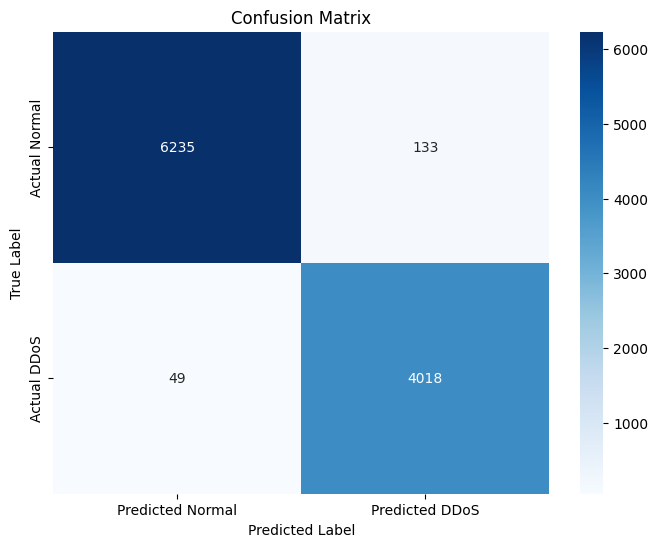


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      6368
           1       0.97      0.99      0.98      4067

    accuracy                           0.98     10435
   macro avg       0.98      0.98      0.98     10435
weighted avg       0.98      0.98      0.98     10435

Accuracy Score: 0.9826


In [ ]:
evaluate_model(model_cnn, X_test_cnn, y_test_cnn)

327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix:


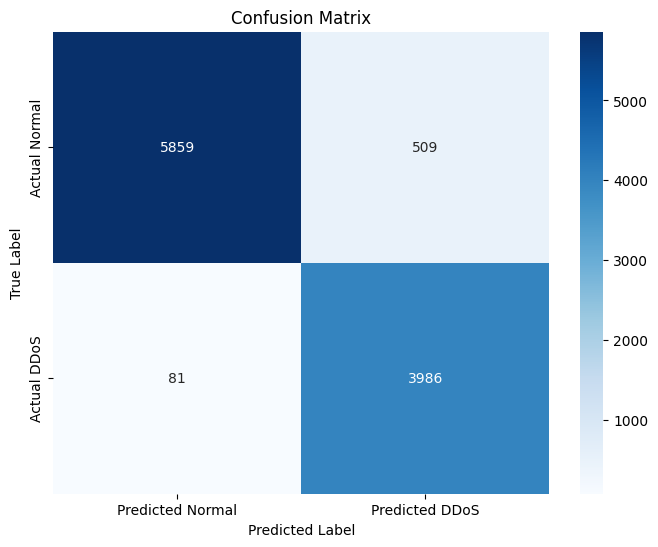


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      6368
           1       0.89      0.98      0.93      4067

    accuracy                           0.94     10435
   macro avg       0.94      0.95      0.94     10435
weighted avg       0.95      0.94      0.94     10435

Accuracy Score: 0.9435


In [ ]:
evaluate_model(model_cnn_five, X_test_cnn_five, y_test_cnn_five)

327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


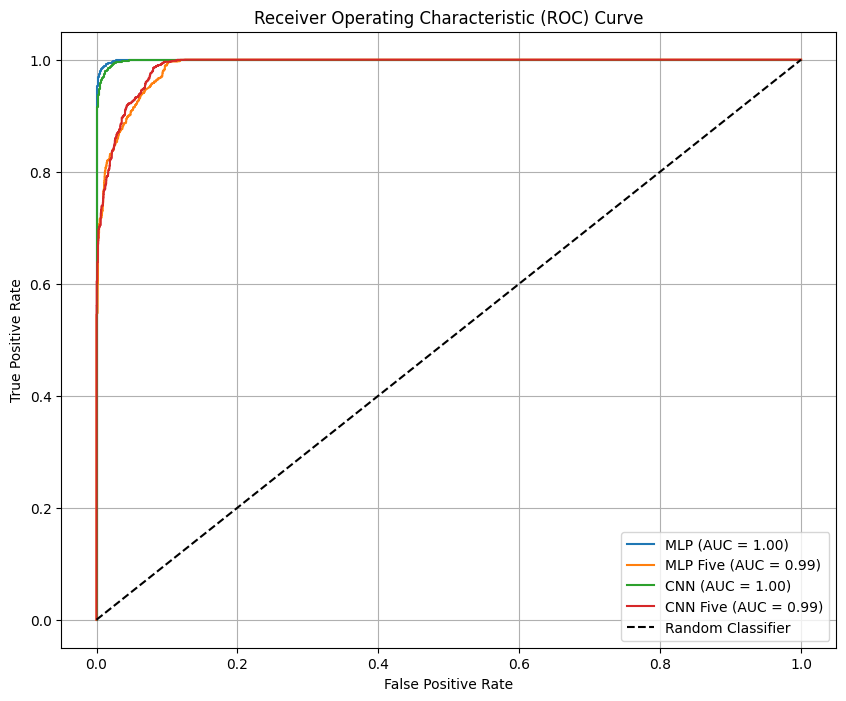

In [ ]:
modelsdata = [
    ('MLP', model_mlp, X_test_mlp, y_test_mlp),
    ('MLP Five', model_mlp_five, X_test_mlp_five, y_test_mlp_five),
    ('CNN', model_cnn, X_test_cnn, y_test_cnn),
    ('CNN Five', model_cnn_five, X_test_cnn_five, y_test_cnn_five)
]

plot_roc_curves(modelsdata)

#Final Results

###Accuracy Scores:

**MLP:** 0.9871

**MLP-5:** 0.9349

**CNN:** 0.9826

**CNN-5:** 0.9435

###Time to train:

**MLP:** 68 seconds

**MLP-5:** 70 seconds

**CNN:** 146 seconds

**CNN-5:** 86 seconds

###Total Parameters (and size)

**MLP:** 10,753 (42.00 KB)

**MLP-5:** 9,089 (35.50 KB)

**CNN:** 80,321 (313.75 KB)

**CNN-5:** 22,977 (89.75 KB)